# PINN for a 2D compressible Neo-Hookean solid — nondimensional formulation

The physical reference domain and manufactured displacement are unchanged:

$$
\Omega_0=[0,1]^2,\qquad
\mathbf{u}(X,Y)=\begin{bmatrix}0.1(X^2+Y^2)\\0.05Y^2\end{bmatrix}.
$$

The plane-strain material has $E=1000$ and $\nu=0.3$ by default.

Hats denote all scaled (dimensionless) quantities. 

The reference scales are defined by

$$
L_{\mathrm{ref}}=\operatorname{diam}\Omega_0=\sqrt{2},\qquad
U_{\mathrm{ref}}=\max_{\Gamma_D}\|\mathbf{u}_D\|_2
=\sqrt{0.2^2+0.05^2}\approx0.206155.
$$

The maximum occurs at $(1,1)$.

Use $\mathbf{X}=L_{\mathrm{ref}}\widehat{\mathbf{X}}$,
$\mathbf{u}=U_{\mathrm{ref}}\widehat{\mathbf{u}}$ and $\mathbf{P}=E\widehat{\mathbf{P}}$.
The network operates entirely on

$$
\widehat{\Omega}_0=[0,1/\sqrt{2}]^2.
$$

With $\alpha=U_{\mathrm{ref}}/L_{\mathrm{ref}}$,

$$
\mathbf{F}=\mathbf{I}+\alpha\nabla_{\widehat{X}}\widehat{\mathbf{u}},\qquad J=\det\mathbf{F}.
$$

Dimensionless material parameters, energy density and stress are

$$
\widehat{\mu}=\frac{1}{2(1+\nu)},\qquad
\widehat{\lambda}=\frac{\nu}{(1+\nu)(1-2\nu)},\qquad \widehat{W}=W/E,
$$

$$
\widehat{W}=\frac{\widehat{\mu}}{2}(I_1-2)-\widehat{\mu}\ln J
+\frac{\widehat{\lambda}}{2}(\ln J)^2,
$$

$$
\widehat{\mathbf{P}}=\widehat{\mu}(\mathbf{F}-\mathbf{F}^{-\mathsf{T}})
+\widehat{\lambda}\ln J\,\mathbf{F}^{-\mathsf{T}}.
$$

Equilibrium is

$$
\operatorname{Div}_{\widehat{X}}\widehat{\mathbf{P}}+\widehat{\mathbf{B}}=\mathbf{0},\qquad
\widehat{\mathbf{B}}(\widehat{\mathbf{X}})=\frac{L_{\mathrm{ref}}}{E}
\mathbf{B}(L_{\mathrm{ref}}\widehat{\mathbf{X}}).
$$

Training, validation and optional displacement data use the same scales.


## 1. Imports


In [1]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Settings

`DOMAIN_SIDE` is the physical side length of the square; `L_REF` is its diameter. `U_REF` is the exact maximum Dirichlet
displacement norm for the manufactured solution.


In [2]:
USE_DATA = False
DATA_MODE = "exact"
NOISE_RELATIVE_STD = 0.02
assert DATA_MODE in {"exact", "noisy"}

DOMAIN_SIDE = 1.0
L_REF = np.sqrt(2.0) * DOMAIN_SIDE
U_REF = np.hypot(0.2 * DOMAIN_SIDE**2, 0.05 * DOMAIN_SIDE**2)
assert L_REF > 0.0 and U_REF > 0.0
DOMAIN_SIDE_HAT = DOMAIN_SIDE / L_REF
ALPHA = U_REF / L_REF
E_YOUNG = 1000.0
POISSON_RATIO = 0.3
MU = E_YOUNG / (2.0 * (1.0 + POISSON_RATIO))
LAME_LAMBDA = (
    E_YOUNG * POISSON_RATIO
    / ((1.0 + POISSON_RATIO) * (1.0 - 2.0 * POISSON_RATIO))
)

assert E_YOUNG > 0.0 and -1.0 < POISSON_RATIO < 0.5
MU_HAT = 1.0 / (2.0 * (1.0 + POISSON_RATIO))
LAME_LAMBDA_HAT = (
    POISSON_RATIO / ((1.0 + POISSON_RATIO) * (1.0 - 2.0 * POISSON_RATIO))
)

N_SIDE_PDE_TRAIN = 35
N_SIDE_PDE_VALIDATION = 12
N_SIDE_PDE_TEST = 12
PDE_BATCH_SIZE = 32
N_BOUNDARY_PER_EDGE = 40

N_DATA_TRAIN = 50
N_DATA_VALIDATION = 20
N_DATA_TEST = 20

EPOCHS = 2000
LBFGS_EPOCHS = 100
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
LR = 1e-3
SEED = 42
WEIGHT = 1.0  # PDE residual and all displacement errors are dimensionless

torch.manual_seed(SEED)
print(f"Young's modulus: {E_YOUNG:.1f}")
print(f"Poisson ratio: {POISSON_RATIO:.3f}")
print(f"Lamé lambda: {LAME_LAMBDA:.6f}")
print(f"Shear modulus mu: {MU:.6f}")
print(f"Displacement data mode: {DATA_MODE}")
if DATA_MODE == "noisy":
    print(f"Relative noise standard deviation: {NOISE_RELATIVE_STD:.1%}")

print(f"Reference diameter: {L_REF:.9f}")
print(f"Reference displacement norm: {U_REF:.9f}")
print(f"U_REF / L_REF: {ALPHA:.9f}")
print(f"Dimensionless square side: {DOMAIN_SIDE_HAT:.9f}")
print(f"Dimensionless mu: {MU_HAT:.9f}; lambda: {LAME_LAMBDA_HAT:.9f}")


Young's modulus: 1000.0
Poisson ratio: 0.300
Lamé lambda: 576.923077
Shear modulus mu: 384.615385
Displacement data mode: exact
Reference diameter: 1.414213562
Reference displacement norm: 0.206155281
U_REF / L_REF: 0.145773797
Dimensionless square side: 0.707106781
Dimensionless mu: 0.384615385; lambda: 0.576923077


## 3. Exact solution, boundary conditions, and body force

Displacement, stress and body force outputs without a `_physical`
suffix are dimensionless. The deformation gradient is dimensionless.
The transformed exact solution is

$$
\widehat{u}_x=\frac{0.1L_{\mathrm{ref}}^2}{U_{\mathrm{ref}}}
\big((\widehat{X})^2+(\widehat{Y})^2\big),\qquad
\widehat{u}_y=\frac{0.05L_{\mathrm{ref}}^2}{U_{\mathrm{ref}}}(\widehat{Y})^2.
$$

Its physical deformation gradient, expressed in dimensionless coordinates, is

$$
\mathbf{F}_{\mathrm{exact}}(\widehat{X},\widehat{Y})=
\begin{bmatrix}1+0.2L_{\mathrm{ref}}\widehat{X}&0.2L_{\mathrm{ref}}\widehat{Y}\\
0&1+0.1L_{\mathrm{ref}}\widehat{Y}\end{bmatrix}.
$$

On all four edges of $\widehat{\Omega}_0$,

$$
\widehat{\mathbf{u}}_D(\widehat{\mathbf{X}})=\mathbf{u}_D(L_{\mathrm{ref}}\widehat{\mathbf{X}})/U_{\mathrm{ref}}.
$$

The analytical manufactured force satisfies

$$
\widehat{\mathbf{B}}=-\operatorname{Div}_{\widehat{X}}\widehat{\mathbf{P}}_{\mathrm{exact}}.
$$



In [3]:
def exact_displacement_physical(xy_physical):
    X = xy_physical[:, 0:1]
    Y = xy_physical[:, 1:2]
    ux = 0.1 * (X**2 + Y**2)
    uy = 0.05 * Y**2
    return torch.cat((ux, uy), dim=1)


def exact_displacement(xy):
    """Dimensionless displacement at dimensionless coordinates."""
    return exact_displacement_physical(L_REF * xy) / U_REF


def exact_deformation_gradient(xy):
    X = L_REF * xy[:, 0:1]
    Y = L_REF * xy[:, 1:2]
    row_1 = torch.cat((1.0 + 0.2 * X, 0.2 * Y), dim=1)
    row_2 = torch.cat((torch.zeros_like(X), 1.0 + 0.1 * Y), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def first_piola_from_F(F):
    """Return dimensionless first Piola stress P/E and determinant J."""
    J = torch.linalg.det(F)
    J_safe = torch.clamp(J, min=1e-8)
    inverse_transpose = torch.linalg.inv(F).transpose(1, 2)
    logarithmic_term = torch.log(J_safe).view(-1, 1, 1)
    P = (MU_HAT * (F - inverse_transpose)
         + LAME_LAMBDA_HAT * logarithmic_term * inverse_transpose)
    return P, J


def exact_nominal_stress(xy):
    """Dimensionless exact first Piola stress at dimensionless coordinates."""
    P, _ = first_piola_from_F(exact_deformation_gradient(xy))
    return P


def body_force(xy):
    """Dimensionless reference force B_hat = (L_REF/E) B(L_REF * xy)."""
    X = L_REF * xy[:, 0:1]
    Y = L_REF * xy[:, 1:2]
    a = 1.0 + 0.2 * X
    b = 0.2 * Y
    c = 1.0 + 0.1 * Y
    q = LAME_LAMBDA_HAT * torch.log(a * c) - MU_HAT

    divergence_x = 0.4 * MU_HAT + 0.2 * (LAME_LAMBDA_HAT - q) / a**2
    divergence_y = (0.1 * MU_HAT
                    + 0.1 * (LAME_LAMBDA_HAT - q) / c**2
                    - 0.2 * b * (LAME_LAMBDA_HAT - q) / (c * a**2))
    return -L_REF * torch.cat((divergence_x, divergence_y), dim=1)


def observed_displacement(xy, seed):
    exact = exact_displacement(xy)
    if DATA_MODE == "exact":
        return exact

    # Preserve the original physical component noise levels, then divide by U_REF.
    component_scales = exact.new_tensor(
        [[0.2 * DOMAIN_SIDE**2, 0.05 * DOMAIN_SIDE**2]]
    ) / U_REF
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * component_scales * noise


## 4. Neural network

The architecture is unchanged. Inputs are $\widehat{\mathbf{X}}$ and outputs are $\widehat{\mathbf{u}}$.


In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 2),
        )


    def forward(self, xy):
        return self.net(xy)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


Trainable parameters: 272


## 5. PDE train, validation, and test points

All three PDE sets are uniform interior Cartesian grids with different within-cell shifts.

Dimensionless coordinates are generated in $[0,1/\sqrt{2}]^2$.
Each dimensionless coordinate is the corresponding original physical
coordinate divided by `L_REF`.


In [5]:
def shifted_uniform_grid_2d(n_side, shift_x, shift_y):
    indices = torch.arange(n_side, dtype=torch.get_default_dtype())
    x = DOMAIN_SIDE_HAT * (indices + shift_x) / n_side
    y = DOMAIN_SIDE_HAT * (indices + shift_y) / n_side
    X, Y = torch.meshgrid(x, y, indexing="xy")
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)


def grids_overlap(first, second):
    differences = torch.abs(first[:, None, :] - second[None, :, :])
    identical = torch.all(differences < 1e-12, dim=2)
    return bool(torch.any(identical))


x_pde_train = shifted_uniform_grid_2d(N_SIDE_PDE_TRAIN, shift_x=0.50, shift_y=0.50)
x_pde_validation = shifted_uniform_grid_2d(N_SIDE_PDE_VALIDATION, shift_x=0.37, shift_y=0.61)
x_pde_test = shifted_uniform_grid_2d(N_SIDE_PDE_TEST, shift_x=0.73, shift_y=0.29)

assert not grids_overlap(x_pde_train, x_pde_validation)
assert not grids_overlap(x_pde_train, x_pde_test)
assert not grids_overlap(x_pde_validation, x_pde_test)

print(
    f"PDE points: {len(x_pde_train)} train, "
    f"{len(x_pde_validation)} validation, {len(x_pde_test)} test"
)
print("PDE grids overlap: False")
print(f"Adam PDE batch size: {PDE_BATCH_SIZE}")

pde_batch_generator = torch.Generator().manual_seed(SEED + 1)
pde_train_loader = DataLoader(TensorDataset(x_pde_train), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator,)


PDE points: 1225 train, 144 validation, 144 test
PDE grids overlap: False
Adam PDE batch size: 32


## 6. Dirichlet boundary points and optional supervised data



Set `DATA_MODE` to `"exact"` or `"noisy"`. In noisy mode, independent Gaussian noise is added to the train, validation, and test displacement observations. Boundary values remain exact.

All boundary and data coordinates and displacements are dimensionless.
Physical noise levels are preserved before normalizing by `U_REF`.


In [6]:
edge_coordinate = torch.linspace(0.0, DOMAIN_SIDE_HAT, N_BOUNDARY_PER_EDGE).view(-1, 1)
zeros = torch.zeros_like(edge_coordinate)
ones = torch.full_like(edge_coordinate, DOMAIN_SIDE_HAT)

xy_boundary = torch.cat(
    (torch.cat((zeros, edge_coordinate), dim=1),
    torch.cat((ones, edge_coordinate), dim=1),
    torch.cat((edge_coordinate, zeros), dim=1),
    torch.cat((edge_coordinate, ones), dim=1),),
    dim=0,)
u_boundary = exact_displacement(xy_boundary)


if USE_DATA:
    train_generator = torch.Generator().manual_seed(SEED + 10)
    validation_generator = torch.Generator().manual_seed(SEED + 11)
    test_generator = torch.Generator().manual_seed(SEED + 12)

    xy_data_train = DOMAIN_SIDE_HAT * torch.rand(N_DATA_TRAIN, 2, generator=train_generator)
    xy_data_validation = DOMAIN_SIDE_HAT * torch.rand(N_DATA_VALIDATION, 2, generator=validation_generator)
    xy_data_test = DOMAIN_SIDE_HAT * torch.rand(N_DATA_TEST, 2, generator=test_generator)

    u_data_train = observed_displacement(xy_data_train, seed=SEED + 20)
    u_data_validation = observed_displacement(xy_data_validation, seed=SEED + 21)
    u_data_test = observed_displacement(xy_data_test, seed=SEED + 22)

    print(
        f"Displacement data: {N_DATA_TRAIN} train, "
        f"{N_DATA_VALIDATION} validation, {N_DATA_TEST} test"
    )
    print(f"Displacement data mode: {DATA_MODE}")

print(f"Dirichlet boundary points: {len(xy_boundary)}")

assert torch.isclose(torch.linalg.vector_norm(u_boundary, dim=1).max(),
                     u_boundary.new_tensor(1.0), atol=1e-6)


Dirichlet boundary points: 160


## 7. Physics residual and training

The network approximates $\widehat{\mathbf{u}}_\theta(\widehat{X},\widehat{Y})$. Automatic differentiation
is with respect to the dimensionless input coordinates:

$$
\mathbf{F}_\theta=\mathbf{I}+\alpha\nabla_{\widehat{X}}\widehat{\mathbf{u}}_\theta,\qquad
J_\theta=\det\mathbf{F}_\theta,
$$

$$
\widehat{\mathbf{P}}_\theta=\widehat{\mu}(\mathbf{F}_\theta-\mathbf{F}_\theta^{-\mathsf{T}})
+\widehat{\lambda}\ln J_\theta\,\mathbf{F}_\theta^{-\mathsf{T}},
$$

$$
\widehat{\mathbf{r}}_\theta=\operatorname{Div}_{\widehat{X}}\widehat{\mathbf{P}}_\theta+\widehat{\mathbf{B}}.
$$

All losses use the original componentwise mean-square convention, now applied
to dimensionless quantities:

$$
\mathcal{L}=\operatorname{mean}((\widehat{\mathbf{r}}_\theta)^2)
+\operatorname{mean}((\widehat{\mathbf{u}}_\theta-\widehat{\mathbf{u}}_D)^2)
+\mathcal{L}_{\mathrm{data}}.
$$




In [ ]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []
validation_loss_history = []
validation_pde_loss_history = []
validation_data_loss_history = []

best_validation_loss = float("inf")
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None


def deformation_gradient_from_displacement(u, xy):
    ux = u[:, 0:1]
    uy = u[:, 1:2]
    grad_ux = torch.autograd.grad(ux, xy, torch.ones_like(ux), create_graph=True, retain_graph=True)[0]
    grad_uy = torch.autograd.grad(uy, xy, torch.ones_like(uy), create_graph=True, retain_graph=True)[0]
    row_1 = torch.cat((1.0 + ALPHA * grad_ux[:, 0:1], ALPHA * grad_ux[:, 1:2]), dim=1)
    row_2 = torch.cat((ALPHA * grad_uy[:, 0:1], 1.0 + ALPHA * grad_uy[:, 1:2]), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def displacement_stress_and_residual(xy, create_graph):
    """Return u_hat, P_hat, r_hat and J at dimensionless input coordinates."""
    xy_local = xy.detach().clone().requires_grad_(True)
    u = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    P, J = first_piola_from_F(F)

    grad_P11 = torch.autograd.grad(P[:, 0, 0:1], xy_local, torch.ones_like(P[:, 0, 0:1]), create_graph=create_graph, retain_graph=True)[0]
    grad_P12 = torch.autograd.grad(P[:, 0, 1:2], xy_local, torch.ones_like(P[:, 0, 1:2]), create_graph=create_graph, retain_graph=True)[0]
    grad_P21 = torch.autograd.grad(P[:, 1, 0:1], xy_local, torch.ones_like(P[:, 1, 0:1]), create_graph=create_graph, retain_graph=True)[0]
    grad_P22 = torch.autograd.grad(P[:, 1, 1:2], xy_local, torch.ones_like(P[:, 1, 1:2]), create_graph=create_graph, retain_graph=True)[0]

    divergence_x = grad_P11[:, 0:1] + grad_P12[:, 1:2]
    divergence_y = grad_P21[:, 0:1] + grad_P22[:, 1:2]
    divergence = torch.cat((divergence_x, divergence_y), dim=1)
    residual = divergence + body_force(xy_local)
    return u, P, residual, J


def compute_training_losses(xy_pde):
    _, _, residual, J = displacement_stress_and_residual(xy_pde, create_graph=True)
    loss_equilibrium = torch.mean((residual )**2)
    loss_pde = loss_equilibrium

    boundary_error = model(xy_boundary) - u_boundary
    loss_bc = torch.mean(boundary_error**2)

    loss_data = (torch.mean((model(xy_data_train) - u_data_train)**2)
        if USE_DATA else torch.tensor(0.0))
    loss = WEIGHT * loss_pde + loss_bc +  loss_data
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    _, _, residual, J = displacement_stress_and_residual(x_pde_validation, create_graph=False)
    loss_equilibrium = torch.mean((residual.detach())**2)
    loss_pde = loss_equilibrium

    with torch.no_grad():
        loss_data = (torch.mean((model(xy_data_validation) - u_data_validation)**2)
            if USE_DATA else torch.tensor(0.0))
    return WEIGHT * loss_pde + loss_data, loss_pde, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss
    global best_validation_data_loss, best_epoch, best_model_state

    model.eval()
    loss, loss_pde, loss_data = compute_validation_losses()
    values = loss.item(), loss_pde.item(), loss_data.item()
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_data_loss_history.append(values[2])

    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss = values[0]
        best_validation_pde_loss = values[1]
        best_validation_data_loss = values[2]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    model.train()
    return values[0]


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    samples = 0

    for (xy_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()

        batch_size = len(xy_pde_batch)
        epoch_sums += np.array([value.detach().item() for value in losses]) * batch_size
        samples += batch_size

    epoch_values = epoch_sums / samples
    loss_history.append(epoch_values[0])
    pde_loss_history.append(epoch_values[1])
    bc_loss_history.append(epoch_values[2])
    data_loss_history.append(epoch_values[3])
    validation_value = update_checkpoint(epoch)

    if epoch % 100 == 0:
        print(
            f"Adam | epoch {epoch:5d} | loss={epoch_values[0]:.3e} "
            f"| PDE={epoch_values[1]:.3e} | BC={epoch_values[2]:.3e} "
            f"| validation={validation_value:.3e}"
        )


optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _ = compute_training_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_training_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_checkpoint(epoch)

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.3e} "
            f"| validation={validation_value:.3e}"
        )


last_model_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_model_state)
model.eval()

print(f"Best epoch: {best_epoch}")
print(f"Best combined validation loss: {best_validation_loss:.6e}")
print(f"Validation PDE loss: {best_validation_pde_loss:.6e}")



Adam | epoch     0 | loss=1.943e-01 | PDE=1.005e-01 | BC=9.378e-02 | validation=1.012e-01
Adam | epoch   100 | loss=1.788e-05 | PDE=1.122e-05 | BC=6.663e-06 | validation=9.658e-06
Adam | epoch   200 | loss=5.267e-06 | PDE=3.817e-06 | BC=1.450e-06 | validation=3.461e-06
Adam | epoch   300 | loss=5.012e-06 | PDE=2.481e-06 | BC=2.531e-06 | validation=2.429e-06
Adam | epoch   400 | loss=2.463e-06 | PDE=1.876e-06 | BC=5.877e-07 | validation=1.759e-06
Adam | epoch   500 | loss=1.777e-06 | PDE=1.514e-06 | BC=2.630e-07 | validation=1.358e-06
Adam | epoch   600 | loss=3.722e-06 | PDE=1.299e-06 | BC=2.423e-06 | validation=1.214e-06
Adam | epoch   700 | loss=1.459e-06 | PDE=1.128e-06 | BC=3.309e-07 | validation=9.900e-07
Adam | epoch   800 | loss=1.191e-06 | PDE=9.755e-07 | BC=2.150e-07 | validation=8.885e-07
Adam | epoch   900 | loss=1.382e-06 | PDE=8.868e-07 | BC=4.956e-07 | validation=7.685e-07
Adam | epoch  1000 | loss=2.114e-06 | PDE=8.039e-07 | BC=1.311e-06 | validation=7.227e-07
Adam | epo

## 8. Final test metrics

Predicted and exact displacement and stress are converted to physical units
before computing the original metrics. Report both dimensionless and physical
MSE values, using

$$
\mathbf{r}=(E/L_{\mathrm{ref}})\widehat{\mathbf{r}},\qquad
\mathrm{MSE}_{u}=U_{\mathrm{ref}}^2\mathrm{MSE}_{\widehat{u}},\qquad
\mathrm{MSE}_{r}=(E/L_{\mathrm{ref}})^2\mathrm{MSE}_{\widehat{r}}.
$$

Relative L2 and R2 scores are unchanged by a common scalar conversion.


In [29]:
model.eval()
u_test_hat, P_test_hat, residual_test_hat, J_test = displacement_stress_and_residual(x_pde_test, create_graph=False)

u_test = U_REF * u_test_hat.detach()
P_test = E_YOUNG * P_test_hat.detach()
residual_test_hat = residual_test_hat.detach()
residual_test = (E_YOUNG / L_REF) * residual_test_hat
J_test = J_test.detach()
u_exact_test = U_REF * exact_displacement(x_pde_test)
P_exact_test = E_YOUNG * exact_nominal_stress(x_pde_test)


def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()


metrics = {
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "displacement_R2_test": r2_score(u_test, u_exact_test),
    "displacement_relative_L2_test": relative_l2(u_test, u_exact_test),
    "nominal_stress_R2_test": r2_score(P_test, P_exact_test),
    "nominal_stress_relative_L2_test": relative_l2(P_test, P_exact_test),
}

print("=" * 62)
print("2D NEO-HOOKEAN PINN TEST RESULTS")
print("=" * 62)
print(f"Displacement R2:              {metrics['displacement_R2_test']:.8f}")
print(f"Displacement relative L2:     {metrics['displacement_relative_L2_test']:.6e}")
print(f"Nominal stress R2:            {metrics['nominal_stress_R2_test']:.8f}")
print(f"Nominal stress relative L2:   {metrics['nominal_stress_relative_L2_test']:.6e}")
print("=" * 62)

metrics


2D NEO-HOOKEAN PINN TEST RESULTS
Displacement R2:              0.99999970
Displacement relative L2:     3.879929e-04
Nominal stress R2:            0.99999779
Nominal stress relative L2:   9.477424e-04


{'best_epoch': 1900,
 'best_validation_loss': 2.8727853873533604e-07,
 'displacement_R2_test': 0.9999997019767761,
 'displacement_relative_L2_test': 0.0003879928553942591,
 'nominal_stress_R2_test': 0.9999977946281433,
 'nominal_stress_relative_L2_test': 0.0009477424318902194}

## 9. Plots

Coordinates, displacement and stress plots use physical units. Loss plots use dimensionless MSE values.


In [ ]:
def regular_grid(n=60):
    values = torch.linspace(0.0, DOMAIN_SIDE_HAT, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    return (L_REF * X).numpy(), (L_REF * Y).numpy(), xy


def predict_u_and_P(xy, state_dict=None):
    current_state = copy.deepcopy(model.state_dict())
    if state_dict is not None:
        model.load_state_dict(state_dict)
    model.eval()

    xy_local = xy.detach().clone().requires_grad_(True)
    u = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    P, J = first_piola_from_F(F)

    model.load_state_dict(current_state)
    model.eval()
    return U_REF * u.detach(), E_YOUNG * P.detach(), J.detach()


PLOT_SIDE = 60
X_plot, Y_plot, xy_plot = regular_grid(PLOT_SIDE)
u_best, P_best, J_best = predict_u_and_P(xy_plot, best_model_state)
u_last, P_last, J_last = predict_u_and_P(xy_plot, last_model_state)
u_exact_plot = U_REF * exact_displacement(xy_plot)
P_exact_plot = E_YOUNG * exact_nominal_stress(xy_plot)


def plot_data_split():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    axes[0].scatter((L_REF * x_pde_train)[:, 0], (L_REF * x_pde_train)[:, 1], s=9,
                    color="tab:blue", alpha=0.45, label=f"train ({len(x_pde_train)})")
    axes[0].scatter((L_REF * x_pde_validation)[:, 0], (L_REF * x_pde_validation)[:, 1], s=18,
                    color="tab:green", marker="s", label=f"validation ({len(x_pde_validation)})")
    axes[0].scatter((L_REF * x_pde_test)[:, 0], (L_REF * x_pde_test)[:, 1], s=18,
                    color="tab:orange", marker="x", label=f"test ({len(x_pde_test)})")
    axes[0].set(xlabel="X", ylabel="Y", title="PDE collocation points")
    axes[0].set_aspect("equal")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].scatter((L_REF * xy_boundary)[:, 0], (L_REF * xy_boundary)[:, 1], s=16,
                    color="black", label="Dirichlet boundary")
    if USE_DATA:
        axes[1].scatter((L_REF * xy_data_train)[:, 0], (L_REF * xy_data_train)[:, 1], s=35,
                        color="tab:blue", label=f"data train ({N_DATA_TRAIN})")
        axes[1].scatter((L_REF * xy_data_validation)[:, 0], (L_REF * xy_data_validation)[:, 1], s=40,
                        color="tab:green", marker="s", label=f"data validation ({N_DATA_VALIDATION})")
        axes[1].scatter((L_REF * xy_data_test)[:, 0], (L_REF * xy_data_test)[:, 1], s=40,
                        color="tab:orange", marker="x", label=f"data test ({N_DATA_TEST})")
    axes[1].set(xlabel="X", ylabel="Y", title=f"Boundary and data ({DATA_MODE})")
    axes[1].set_aspect("equal")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.savefig(OUTPUT_DIR / "hyperelastic_2d_dimensionless_points_and_data.pdf", bbox_inches="tight")
    plt.show()


def plot_field_rows(exact, predicted, names, filename, figure_title):
    number_of_fields = len(names)
    fig, axes = plt.subplots(
        number_of_fields, 3,
        figsize=(13, 3.8 * number_of_fields),
        squeeze=False,
        constrained_layout=True,
    )

    for row, name in enumerate(names):
        exact_field = exact[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        predicted_field = predicted[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        scale = max(np.max(np.abs(exact_field)), np.finfo(float).eps)
        error_field = np.abs(predicted_field - exact_field) / scale
        common_limit = max(np.max(np.abs(exact_field)), np.max(np.abs(predicted_field)))

        exact_image = axes[row, 0].pcolormesh(
            X_plot, Y_plot, exact_field, shading="auto", cmap="coolwarm",
            vmin=-common_limit, vmax=common_limit)
        axes[row, 1].pcolormesh(
            X_plot, Y_plot, predicted_field, shading="auto", cmap="coolwarm",
            vmin=-common_limit, vmax=common_limit)
        error_image = axes[row, 2].pcolormesh(
            X_plot, Y_plot, error_field, shading="auto", cmap="viridis",
            vmin=0.0)

        titles = [f"Exact {name}", f"PINN {name}", f"Normalized error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="X", ylabel="Y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, :2], shrink=0.85)
        fig.colorbar(error_image, ax=axes[row, 2], shrink=0.85)

    fig.suptitle(figure_title)
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_solution():
    plot_field_rows(u_exact_plot, u_best, [r"$u_x$", r"$u_y$"], "hyperelastic_2d_dimensionless_displacement.pdf", "Displacement")

    exact_P_flat = P_exact_plot.reshape(-1, 4)
    predicted_P_flat = P_best.reshape(-1, 4)
    plot_field_rows(exact_P_flat,
        predicted_P_flat, [r"$P_{11}$", r"$P_{12}$", r"$P_{21}$", r"$P_{22}$"], "hyperelastic_2d_dimensionless_first_piola.pdf", "First Piola--Kirchhoff stress")


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, alpha=0.70, label="total")
    axes[0].plot(pde_loss_history, alpha=0.65, label="PDE")
    axes[0].plot(bc_loss_history, alpha=0.65, label="Dirichlet boundary")
    if USE_DATA:
        axes[0].plot(data_loss_history, alpha=0.65, label="supervised data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="dimensionless loss", title="Training losses")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(validation_loss_history, alpha=0.70, label="combined validation")
    axes[1].plot(validation_pde_loss_history, alpha=0.65, label="PDE")
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, alpha=0.65, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="dimensionless loss", title="Validation losses")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_2d_dimensionless_losses.pdf", bbox_inches="tight")
    plt.show()




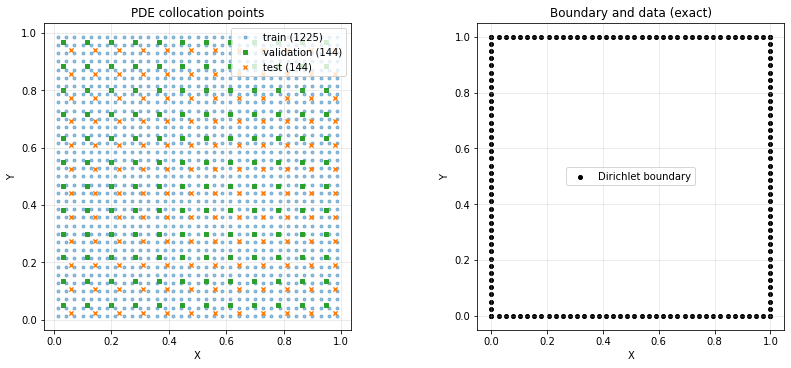

In [25]:
plot_data_split()


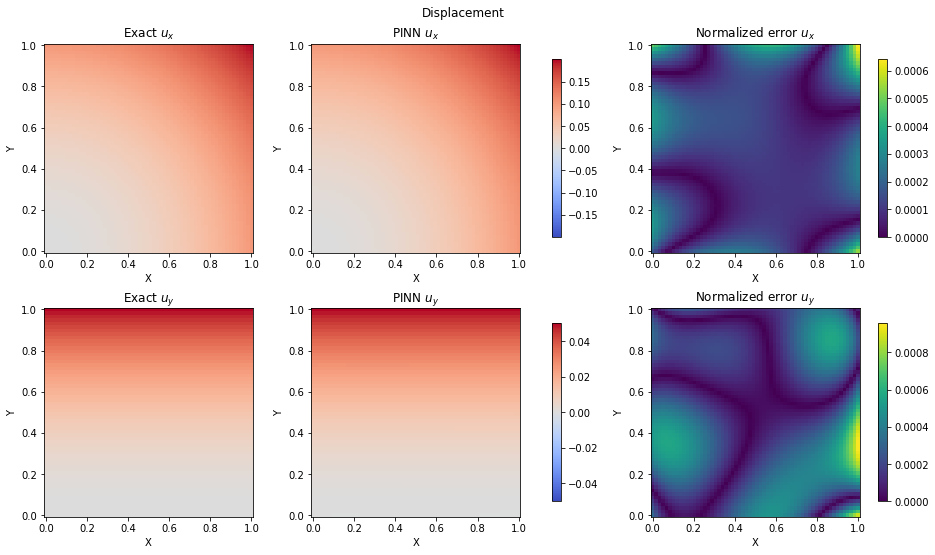

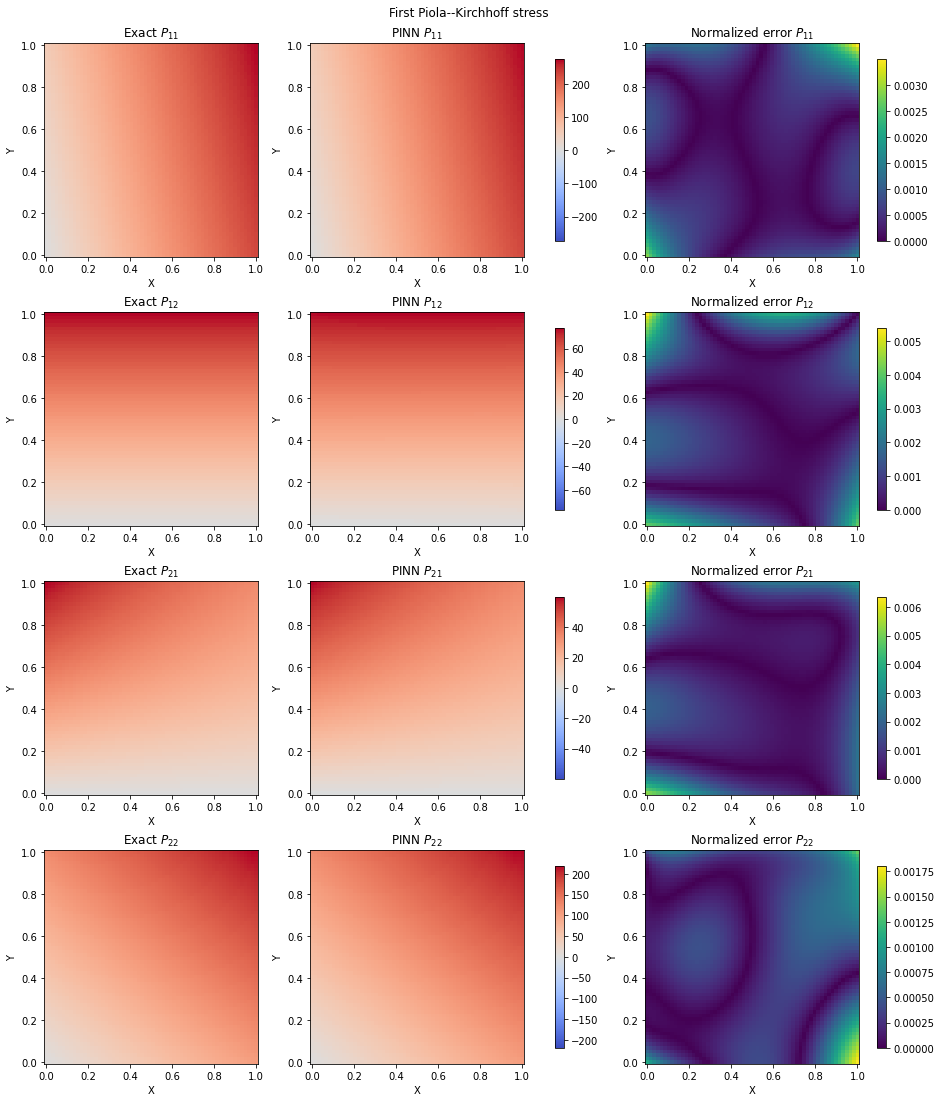

In [26]:
plot_solution()


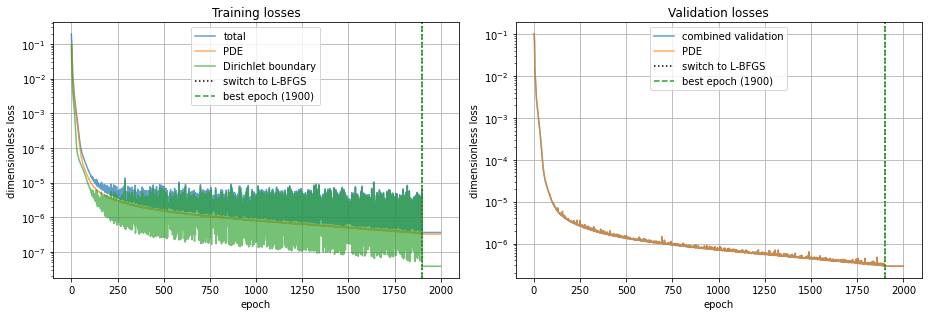

In [27]:
plot_losses()
